In [2]:
import cv2
import matplotlib.pyplot as plt
import winsound
import time
import random
import IPython
import tqdm
import concurrent.futures
import os


# vars and funcs

In [3]:
class FaceProcessor:
    def __init__(self, default_margin=30):
        self.default_margin = default_margin

    def get_safe_margin(self, frame_shape, x, y, w, h):
        h_f, w_f, _ = frame_shape
        # Calculate distance to all 4 edges
        max_m = min(x, y, w_f - (x + w), h_f - (y + h))
        return max(0, min(self.default_margin, max_m))

    def crop(self, frame, coords):
        (x, y), (w, h) = coords[0], coords[1]

        if w <= 0 or h <= 0:
            return None

        margin = self.get_safe_margin(frame.shape, x, y, w, h)

        crop = frame[y-margin : y+h+margin, x-margin : x+w+margin]
        return crop

In [4]:

def load_landmarks(point_file):
    """Parses CASIA-FASD text files."""
    points = {}
    with open(point_file, 'r') as f:
        for line in f:
            data = list(map(int, line.split()))
            # Map: {frame_idx: [(x,y), (w,h), (eyeL), (eyeR)]}
            points[data[0]] = [(data[1], data[2]), (data[3], data[4]),
                               (data[5], data[6]), (data[7], data[8])]
    return points

def videoToProcessedFrames(videoPath,points ,margin=10):
    cap = cv2.VideoCapture(videoPath)
    frames = []
    frame_number = 0
    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_number in points:
            topCorner = points[frame_number][0]
            faceShape = points[frame_number][1]
            prossecor = FaceProcessor(default_margin=margin)
            margin = prossecor.get_safe_margin(frame.shape, topCorner[0], topCorner[1], faceShape[0], faceShape[1])
            frame = prossecor.crop_and_resize(frame, [topCorner, faceShape]) if frame_number in points else None
            if frame is not None:
                frames.append(frame)

        frame_number += 1

    cap.release()
    return frames

def videoToFrames(videoPath):
    cap = cv2.VideoCapture(videoPath)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    cap.release()
    return frames

def displayFrame(frame):
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.show()

def displayFrames(frames,speed=1):
    for i, frame in enumerate(frames):
        if i % speed == 0:
            displayFrame(frame)
            IPython.display.clear_output(wait=True)

def saveFrames(data, dataFolder,margin=30):
    for path, newPath in tqdm(data.items(), desc="Processing videos"):
        videoPath = path + videoExtention
        pointsPath = path + keyPointsExtention
        points = load_landmarks(pointsPath)
        frames = videoToProcessedFrames(videoPath, points, margin=margin)
        for i, frame in enumerate(frames):
            savePath = dataFolder + newPath + f'{i:03}.jpg'
            if not os.path.exists(os.path.dirname(savePath)):
                os.makedirs(os.path.dirname(savePath))
            cv2.imwrite(savePath, frame)

# ////////////////////////////////////////////////////////////////////////

def is_coordinate_valid(point):
    if point is None:
        return False
    (x, y), (w, h) = point[0], point[1]
    return w > 0 and h > 0

def process_video_to_disk(video_path, points_path, output_prefix, processor ,skipingRate = 1):
    points = load_landmarks(points_path)
    cap = cv2.VideoCapture(video_path)

    ret, frame = cap.read()
    frame_idx = 0
    last_point = None
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frame_idx += 1

        if skipingRate:
          if frame_idx % skipingRate != 0:
              frame_idx += 1
              continue

        if frame_idx in points:
            point = points[frame_idx]
            last_point = point
        else:
            point = last_point

        if not is_coordinate_valid(point):
            point = next((p for p in points.values() if is_coordinate_valid(p)), None)

        processed = processor.crop(frame, point)
        if processed is not None:
            save_path = f"{output_prefix}{frame_idx:03d}.jpg"
            if not os.path.exists(os.path.dirname(save_path)):
                os.makedirs(os.path.dirname(save_path))
            cv2.imwrite(save_path, processed)

    cap.release()

def parallel_process(data_dict, processor, max_workers=4, skipingRate = 1):
    """
    Processes multiple videos in parallel using CPU threads.
    """
    # Wrap the process_video_to_disk function from earlier
    video_list = list(data_dict.items())
    print(f"Total videos to process: {len(video_list)}")

    with tqdm.tqdm(total=len(video_list), desc="GPU-Ready Processing") as pbar:
        with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = []
            for path, newPath in video_list:
                # Construct paths
                v_path = path + ".avi"
                p_path = path + ".txt"

                # Submit to threads
                futures.append(executor.submit(process_video_to_disk, v_path, p_path, newPath, processor,skipingRate))

            for future in concurrent.futures.as_completed(futures):
                pbar.update(1)

In [13]:

path = "./data/CASIA_FASD/train_release"
training_path = "./data/CASIA_FASD/train_release/"
testing_path = "./data/CASIA_FASD/test_release/"
pathsfile = "./data/CASIA_FASD/train_release/train.txt"
videoExtention = ".avi"
keyPointsExtention = ".txt"
dataV1TrainPath = "./data/CASIA_FASD_V1/train_release/"
dataV1TestPath = "./data/CASIA_FASD_V1/test_release/"
realPath = "real/"
spoofPath = "spoof/"

destinationDataPath = "./data/CASIA_FASD_V4/"

# casia dataset

In [14]:
data = {}
new_subject_id = 0

for subject in range(1, 21):
    new_subject_id += 1
    new_video_id = 0

    for video in range(1, 9):
        new_video_id += 1
        path = training_path + str(subject) + "/" + str(video)

        if video <= 2:
            data[path] = destinationDataPath + f"{new_subject_id:02}/real/{new_subject_id:02}_{new_video_id:02}_"
        else:
            data[path] = destinationDataPath + f"{new_subject_id:02}/spoof/{new_subject_id:02}_{new_video_id:02}_"


    for j in range(1, 5):
        path = training_path + str(subject) + "/HR_" + str(j)
        new_video_id += 1

        if j <= 1:
            data[path] = destinationDataPath + f"{new_subject_id:02}/real/{new_subject_id:02}_{new_video_id:02}_"
        else:
            data[path] = destinationDataPath + f"{new_subject_id:02}/spoof/{new_subject_id:02}_{new_video_id:02}_"



for subject in range(1, 31):
    new_subject_id += 1
    new_video_id = 0

    for j in range(1, 9):
        path = testing_path + str(subject) + "/" + str(j)
        new_video_id += 1

        if j <= 2:
            data[path] = destinationDataPath + f"{new_subject_id:02}/real/{new_subject_id:02}_{new_video_id:02}_"
        else:
            data[path] = destinationDataPath + f"{new_subject_id:02}/spoof/{new_subject_id:02}_{new_video_id:02}_"



    for j in range(1, 5):
        path = testing_path + str(subject) + "/HR_" + str(j)
        new_video_id += 1

        if j <= 1:
            data[path] = destinationDataPath + f"{new_subject_id:02}/real/{new_subject_id:02}_{new_video_id:02}_"
        else:
            data[path] = destinationDataPath + f"{new_subject_id:02}/spoof/{new_subject_id:02}_{new_video_id:02}_"

data

{'./data/CASIA_FASD/train_release/1/1': './data/CASIA_FASD_V4/01/real/01_01_',
 './data/CASIA_FASD/train_release/1/2': './data/CASIA_FASD_V4/01/real/01_02_',
 './data/CASIA_FASD/train_release/1/3': './data/CASIA_FASD_V4/01/spoof/01_03_',
 './data/CASIA_FASD/train_release/1/4': './data/CASIA_FASD_V4/01/spoof/01_04_',
 './data/CASIA_FASD/train_release/1/5': './data/CASIA_FASD_V4/01/spoof/01_05_',
 './data/CASIA_FASD/train_release/1/6': './data/CASIA_FASD_V4/01/spoof/01_06_',
 './data/CASIA_FASD/train_release/1/7': './data/CASIA_FASD_V4/01/spoof/01_07_',
 './data/CASIA_FASD/train_release/1/8': './data/CASIA_FASD_V4/01/spoof/01_08_',
 './data/CASIA_FASD/train_release/1/HR_1': './data/CASIA_FASD_V4/01/real/01_09_',
 './data/CASIA_FASD/train_release/1/HR_2': './data/CASIA_FASD_V4/01/spoof/01_10_',
 './data/CASIA_FASD/train_release/1/HR_3': './data/CASIA_FASD_V4/01/spoof/01_11_',
 './data/CASIA_FASD/train_release/1/HR_4': './data/CASIA_FASD_V4/01/spoof/01_12_',
 './data/CASIA_FASD/train_relea

In [ ]:
parallel_process(data, FaceProcessor(default_margin=30),skipingRate=0)

Total videos to process: 600


GPU-Ready Processing: 100%|██████████| 600/600 [03:40<00:00,  2.72it/s]


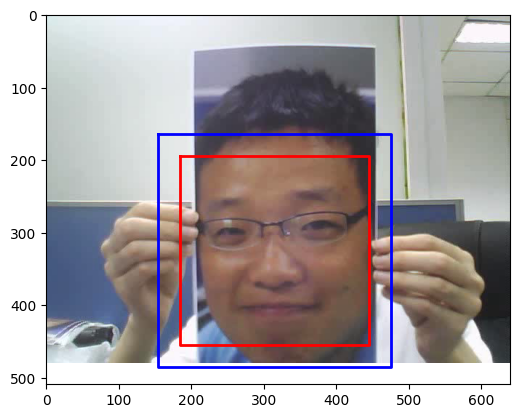

In [12]:
path = "./data/CASIA_FASD/test_release/5/3"
cap = cv2.VideoCapture(f"{path}.avi")
img = cap.read()[1]

with open(f"{path}.txt", 'r') as f:
    points = list(map(int, f.readline().split()))
_, x, y, w, h, lex, ley, rex, rey = points

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.plot([x, x+w, x+w, x, x], [y, y, y+h, y+h, y], color='red', linewidth=2)
margin = 30
plt.plot([x-margin, x+w+margin, x+w+margin, x-margin, x-margin], [y-margin, y-margin, y+h+margin, y+h+margin, y-margin], color='blue', linewidth=2)

plt.show()

In [ ]:
totalFrames = 0
maxFrames = 0
for vid in data.keys():
    video_path = vid + ".avi"
    while True:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error opening video file: {video_path}")
            break
        totalFrames += int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        maxFrames = max(maxFrames, int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
        cap.release()
        break

print(f"Total frames across all videos: {totalFrames}")
print(f"Maximum frames in a single video: {maxFrames}")


In [ ]:
pic1 = "CASIA_FASD_V1\\train_release\\real\\1_1_0.jpg"
pic2 = "CASIA_FASD_V1\\train_release\\real\\1_1_1.jpg"

frame1 = cv2.imread(pic1)
frame2 = cv2.imread(pic2)

# im_shape = (100, 150, 3)
# frame1 = cv2.resize(frame1, (im_shape[1], im_shape[0]))
# frame2 = cv2.resize(frame2, (im_shape[1], im_shape[0]))

# cv2.normalize(frame1, frame2, 0, 255, cv2.NORM_MINMAX)
# # cv2.normalize(frame2, frame2, 0, 255, cv2.NORM_MINMAX)
diff = cv2.subtract(frame1, frame2)
diff2 = cv2.absdiff(frame1, frame2)
diff3 = abs(frame1- frame2)

fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
ax = fig.add_subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
ax = fig.add_subplot(1, 4, 3)
plt.imshow(cv2.cvtColor(diff, cv2.COLOR_BGR2RGB))
ax = fig.add_subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(diff2, cv2.COLOR_BGR2RGB))

plt.show()

print(diff.sum())
print(diff.mean())

print(diff2.sum())
print(diff2.mean())

print(diff3.sum())
print(diff3.mean())




In [ ]:
def get_best_frames(video_path, skip_threshold=0.98, max_frames=10):
    cap = cv2.VideoCapture(video_path)
    extracted_frames = []
    prev_frame = None
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        # 1. Convert to gray for analysis
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # 2. Redundancy Check (MSE or SSIM)
        if prev_frame is not None:
            score = cv2.matchTemplate(gray, prev_frame, cv2.TM_CCORR_NORMED)[0][0]
            print(f"Similarity score: {score:.4f}")
            if score > skip_threshold: # Too similar to previous frame
                continue
        
        # 3. Quality Check (Blurry detection)
        sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
        
        extracted_frames.append((sharpness, frame))
        prev_frame = gray
        
    cap.release()
    
    # 4. Sort by sharpness and pick the top N
    extracted_frames.sort(key=lambda x: x[0], reverse=True)
    return [f[1] for f in extracted_frames[:max_frames]]

In [ ]:
import Katna.frame_extractor as fe
frameExtractor = fe.FrameExtractor()

path = "CASIA_FASD/train_release/1"


In [ ]:
frames = 0
# lines = 0

# valid = 0
# invalid = 0

# non_black_frames = 0

l = ['1', '2', '3', '4', '5', '6', '7', '8', 'HR_1', 'HR_2', 'HR_3', 'HR_4']
train_test_paths = ["./CASIA_FASD/train_release", "./CASIA_FASD/test_release"]

def count_non_black_frames(video_path, threshold=10):
    cap = cv2.VideoCapture(video_path)
    non_black_frames = 0
    total_frames = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        total_frames += 1
        if cv2.countNonZero(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)) >= threshold:
            non_black_frames += 1
            
    cap.release()
    return non_black_frames, total_frames  

def is_coordinate_valid(point):
    if point is None:
        return False
    (x, y), (w, h) = point[0], point[1]
    return w > 0 and h > 0

def count(video_path, points_path, processor):
    points = load_landmarks(points_path)
    cap = cv2.VideoCapture(video_path)

    ret, frame = cap.read()
    frame_idx = 0
    last_point = None
    res = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frame_idx += 1

        if frame_idx in points:
            point = points[frame_idx]
            last_point = point
        else:
            point = last_point
            # print(f"Frame {frame_idx} in {points_path} is missing coordinates, using last known point.")

        if not is_coordinate_valid(point):
            point = next((p for p in points.values() if is_coordinate_valid(p)), None)
            # print(f"Frame {frame_idx} in {points_path} is missing valid coordinates, using next available point.")
            

        processed = processor.crop_and_resize(frame, point)
        if processed is not None:
            res += 1
        # else:
            # print(f"Failed to process frame {frame_idx} in {video_path}")
       

    cap.release()
    return res

# extracted_frames = 0
# extracted_frames1 = 0
extracted_frames2 = 0
for path in train_test_paths:
    for subpath in os.listdir(path):
        if os.path.isdir(os.path.join(path, subpath)):
            for name in l:
                vid = name + ".avi"
                text = name + ".txt"
                video_path = os.path.join(path, subpath, vid)
                text_path = os.path.join(path, subpath, text)
                
                # landmarks = load_landmarks(text_path)
                # vid_non_black_frames, vid_total_frames = count_non_black_frames(video_path)
                # non_black_frames += vid_non_black_frames

                extracted = count(video_path, text_path, FaceProcessor())
                extracted_frames2 += extracted
                
                total_frames = 0
                cap = cv2.VideoCapture(video_path)
                while True:
                    if not cap.isOpened():
                        print(f"Error opening video file: {video_path}")
                        break
                    ret, frame = cap.read()
                    if not ret: break
                    total_frames += 1
                   
                cap.release()
                
                # difference = total_frames - extracted
                # if difference > 0:
                #     print(f"Difference: {difference}, file: {text_path}")

                # best_frames = frameExtractor.extract_candidate_frames(video_path)
                # l=len(best_frames)
                frames += total_frames

                # total_lines = len(landmarks)     
                # lines += total_lines

                # for landmark in landmarks:                    
                #     (x, y), (w, h) = landmarks[landmark][0], landmarks[landmark][1]
                #     if w <= 0 or h <= 0:
                #         # print(f"Invalid bounding box with non-positive width or height in {text_path}: (x={x}, y={y}, w={w}, h={h})")
                #         invalid += 1
                #     else:
                #         valid += 1

                # if total_frames != total_lines:
                #     print(f"Mismatch :difference={total_frames - total_lines}, frames={total_frames}, lines={total_lines} in {text_path}")



In [ ]:
print(f"Total extracted frames: {frames}") 
print(f"Total lines in text files: {lines}") 
print (f"Difference: {frames - lines}")
print(f"Valid bounding boxes: {valid}")
print(f"Invalid bounding boxes: {invalid}")
print(f"Total non-black frames: {non_black_frames}")
print(f"Total extracted frames: {extracted_frames}")
print(f"Total extracted frames: {extracted_frames1}")
print(f"Total extracted frames2: {extracted_frames2}")

In [ ]:
frames - extracted_frames2

In [ ]:
video_path = "./CASIA_FASD/train_release/10/HR_3.avi"
len1 = cv2.VideoCapture(video_path).get(cv2.CAP_PROP_FRAME_COUNT)
print(len1)

len2 = 0
cap = cv2.VideoCapture(video_path)
while True:
    if not cap.isOpened():
        print(f"Error opening video file: {video_path}")
        break
    ret, frame = cap.read()
    if not ret: break
    len2 += 1
    
cap.release()
print(len2)

In [ ]:
count_non_black_frames('./CASIA_FASD/test_release/24/HR_2.avi')

In [ ]:
cap = cv2.VideoCapture('./CASIA_FASD/test_release/24/HR_2.avi')
ret, frame = cap.read()
ret, frame = cap.read()

displayFrame(frame)

In [ ]:
import Katna.image_selector as fs
frameSelector = fs.ImageSelector()
video_path = "CASIA_FASD/train_release/1/1.avi"
key_frames =[] 
cap = cv2.VideoCapture(video_path)
cap.get(cv2.CAP_PROP_FRAME_COUNT)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    key_frames.append(frame)

best_frames = frameSelector.select_best_frames(key_frames, len(key_frames)//2)
displayFrames(best_frames)

In [ ]:
cap.get(cv2.CAP_PROP_FRAME_COUNT)

In [ ]:
displayFrames(best_frames)

# NUUA dataset

In [ ]:
import os

l=[]
path = "./Detectedface/ImposterFace"
for folder in os.listdir(path):
    folder_path = os.path.join(path, folder)
    if os.path.isdir(folder_path):
        # print(f"Number of files in {folder}: {len(os.listdir(folder_path))}")
        l.append(len(os.listdir(folder_path)))

s=7
print("spoof faces",l)
print("  total:", sum(l))
print("  train:", sum(l[0:s]), ".. 1 to" , s+1)
print("  test:", sum(l[s:]), ".." , s+2, "to", len(l))

print()

l=[]
path = "./Detectedface/ClientFace"
for folder in os.listdir(path):
    folder_path = os.path.join(path, folder)
    if os.path.isdir(folder_path):
        # print(f"Number of files in {folder}: {len(os.listdir(folder_path))}")
        l.append(len(os.listdir(folder_path)))

s=7
print("live faces",l)
print("  total:", sum(l))
print("  train:", sum(l[0:s]), ".. 1 to" , s+1)
print("  test:", sum(l[s:]), ".." , s+2, "to", len(l))

In [ ]:
import shutil
destPath_train_real = "./NUAA/train_release/real/"
destPath_train_spoof = "./NUAA/train_release/spoof/"

destPath_test_real = "./NUAA/test_release/real"
destPath_test_spoof = "./NUAA/test_release/spoof"



sourcePath_real = "./Detectedface/ClientFace/"
sourcePath_spoof = "./Detectedface/ImposterFace/"

def copyFiles(source_folder : str, dest_folder : str):
    # if not os.path.exists(dest_folder):
    #     os.makedirs(dest_folder)
    for file in os.listdir(source_folder):
        source_file = os.path.join(source_folder, file)
        dest_file = os.path.join(dest_folder, file)
        print(f"Copying {source_file} to {dest_file}")
        shutil.copy(source_file, dest_file)

def fileCount(folder):
    count = 0
    for file in os.listdir(folder):
        if os.path.isfile(os.path.join(folder, file)):
            count += 1
    return count


In [ ]:
imposter_path = "./Detectedface/ImposterFace"
client_path = "./Detectedface/ClientFace"
imposter_subjects = sorted(os.path.join(imposter_path, folder) for folder in os.listdir(imposter_path))
client_subjects = sorted(os.path.join(client_path, folder) for folder in os.listdir(client_path))

separate_index = 7  # Assuming first 7 are for training and the rest for testing

data = {
    destPath_train_real : client_subjects[:separate_index],
    destPath_train_spoof : imposter_subjects[:separate_index],
    
    destPath_test_real: client_subjects[separate_index:],
    destPath_test_spoof: imposter_subjects[separate_index:]
}

total = 0
for dest in data.keys() :
    if not os.path.exists(dest):
        os.makedirs(dest)
    for source in data[dest] :
        copyFiles(source,dest)
        total += 1


# for folder in os.listdir(imposter_path):
#     folder_path = os.path.join(imposter_path, folder)
#     if os.path.isdir(folder_path):
#         print(folder_path)
        

In [ ]:
import os

for i in range(1, 17):
    livepath = f"NUAA_V2/{i:04}/live/"
    spoofpath = f"NUAA_V2/{i:04}/spoof/"
    os.makedirs(livepath, exist_ok=True)
    os.makedirs(spoofpath, exist_ok=True)

In [ ]:
for dir in os.listdir("./detectedface/ClientFace"):
    copyFiles(os.path.join("./detectedface/ClientFace", dir), os.path.join("./NUAA_V2", dir,"live"))

In [ ]:
for dir in os.listdir("./detectedface/ImposterFace"):
    copyFiles(os.path.join("./detectedface/ImposterFace", dir), os.path.join("./NUAA_V2", dir,"spoof"))

In [ ]:
total = 0
for dir in os.listdir("./NUAA_V2"):
    for subdir in os.listdir(os.path.join("./NUAA_V2", dir)):
        for file in os.listdir(os.path.join("./NUAA_V2", dir, subdir)):
            total += 1
            
print(f"Total frames across all videos: {total}")